## **Sampler Square**

### **1. Packages**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import math

from typing import Callable, Optional, List, Mapping, Union, Literal, get_args

from bernet.contracts import SamplerABC, BatchSample
from bernet.utils.statistics import lhs_1, lhs_d
from bernet.utils.validation import TypeCheck
from bernet.utils.validation import ValueCheck

### **2. Implementation**

In [2]:
Side = Literal["top", "bottom", "left", "right"]

class SQUARESampler(SamplerABC):
    """
    Sampler for PINNs on the unit square [0,1]^2.

    Attributes
    ----------
    _n_it : int
        Number of interior points.
    _n_bc : int
        Number of boudanry points per side.
    _n_in : int
        Number of initial condition points.
    _n_ob : int
        Number of observational points.
    _n_mt : int
        Number of metrics points.
    _n_rs : int
        Number of residual points.
    _ratio : List[float]
        Ratio between the number of points normalize by its maximum value.
    _batches : List[Batch]
        List with batches.
    _metrics : Mapping[str, torch.Tensor]
        Metrics data.

    Methods
    -------
    generate() -> int
        Generates residual and boundary points and prepares batches.
    batch(index: int) -> Batch
        Returns a Batch object with residual, boundary, and observational
        points for the given batch index.
    metrics() -> Mapping[str, torch.Tensor]
        Returns the test (metrics) dataset as a mapping.

    Notes
    -----
    - Residual (interior) points via LHS in 2D using ``lhs_d``.
    - Boundary points on all four edges using 1D LHS ``lhs_1``.
    - Independent test (metrics) set via LHS.
    - Batching with reshuffle or not each epoch via ``generate``.
    """
    
    def __init__(
            self,
            interior_h: float,
            boundary_h: Optional[float] = None,
            *,
            initial_h: Optional[float] = None,
            ratio_ob: Optional[float] = .1,
            ratio_mt: Optional[float] = .1,
            padding: Optional[float] = .01,
            batch_size: Optional[int] = 50,
            include_corners: bool = True,
            keep_ratio: bool = True,
            resample: bool = True,
            remove: List[Side] = None,
            func: Callable[[np.ndarray], np.ndarray] = lambda x: np.zeros(shape=[x.shape[0], 1]),
            dtype: torch.dtype = torch.float32,
        ) -> None:
        """
        Parameters
        ----------
        interior_h : float
            Target mean spacing for interior residual points.
        boundary_h : Optional[float]
            Target mean spacing along boundary edges.
        initial_h : Optional[float]
            Target mean spacing along initial condition edge.
        ratio_ob : Optional[float]
            Ratio between the observational data and interior data.
        ratio_mt : Optional[float]
            Ratio between the metrics data and interior data.
        padding : Optional[float]
            Spacing between the internal points and boundary points.
        batch_size : Optional[int]
            Batch size for training.
        include_corners : bool
            If True, ensures the four corners of the unit square are included
            in the boundary set (if boundary sampling is enabled).
        keep_ratio : bool
            If True, keep the ratio of number of points in each batch.
        resample : bool
            If True, resample every time generate is called.
        remove : List[Side]
            Remove the corresponding sides from the boundary.
        func : Callable[[np.ndarray], np.ndarray]
            Return the true solution for boundary, observational, and metrics points.
        dtype : torch.dtype
            Data type for torch tensors.
        """
        super().__init__()

        #-- Type check
        TypeCheck.float(interior_h)
        TypeCheck.float_none(boundary_h)
        TypeCheck.float_none(initial_h)
        TypeCheck.float_none(ratio_ob)
        TypeCheck.float_none(ratio_mt)
        TypeCheck.int_none(batch_size)
        TypeCheck.bool(include_corners)
        TypeCheck.bool(keep_ratio)
        TypeCheck.bool(resample)
        TypeCheck.callable(func)
        TypeCheck.torch_dtype(dtype)
        
        if remove is not None:
            TypeCheck.iterable(remove)
            for side in remove:
                ValueCheck.on_iterable(side, get_args(Side))

        #-- Inputs
        self._interior_h = interior_h
        self._boundary_h = boundary_h
        self._initial_h = initial_h
        self._ratio_ob = ratio_ob
        self._ratio_mt = ratio_mt
        self._padding = padding if padding is not None else 0.0
        self._batch_size = batch_size
        self._include_corners = include_corners
        self._keep_ratio = keep_ratio
        self._resample = resample
        self._remove = remove if remove is not None else []
        self._func = func
        self._dtype = dtype

        #-- Number of points
        self._n_it = int(math.ceil(1.0 / (self._interior_h ** 2)))                                      # Number of interior points
        self._n_bc = int(math.ceil(1.0 / (self._boundary_h))) if self._boundary_h is not None else 0    # Number of boudanry points per side
        self._n_in = int(math.ceil(1.0 / (self._initial_h))) if self._initial_h is not None else 0      # Number of initial condition points
        self._n_ob = int(math.floor(self._ratio_ob * self._n_it)) if self._ratio_ob is not None else 0  # Number of observational points
        self._n_mt = int(math.floor(self._ratio_mt * self._n_it)) if self._ratio_mt is not None else 0  # Number of metrics points
        self._n_rs = self._n_it - self._n_ob - self._n_mt                                               # Number of residual points

        #-- Ratio between different samples
        if self._keep_ratio:
            ns = np.array([self._n_rs, self._n_bc, self._n_in, self._n_ob])
            ns_arg_max = np.argmax(ns)
            self._ratio = ns / ns[ns_arg_max]
        else:
            self._ratio = np.ones(4)
        
        #-- Output
        self._batches: List[BatchSample] = None
        self._metrics: Mapping[str, torch.Tensor] = None

        return
    #----------------------------------------------------------------#
    #-- Override
    def generate(self) -> int:
        if self._batches is None or self._resample:
            super().generate()
            x_rs, x_bc, x_in, x_ob, x_mt = self._generate_points()
            num_batches, indexes_rs, indexes_bc, indexes_in, indexes_ob = self._generate_indexes(x_rs, x_bc, x_in, x_ob)
            self._generate_train_test(num_batches, x_rs, x_bc, x_in, x_ob, x_mt, indexes_rs, indexes_bc, indexes_in, indexes_ob)
        return len(self._batches)
    
    #-- Override
    def batch(self, index: int) -> BatchSample:
        super().batch(index)
        return self._batches[index]
    
    #-- Override
    def metrics(self) -> Mapping[str, torch.Tensor]:
        super().metrics()
        return self._metrics
    
    #----------------------------------------------------------------#
    #-- Auxiliary
    def _generate_points(self) -> List[np.ndarray]:
        """Generate points"""

        #-- Resample interior points
        x_it = (1 - self._padding) * lhs_d(n=self._n_it, d=2) + 0.5 * self._padding   # Interior points

        #-- Separate observational, metric, and residual data
        ids_it = np.random.permutation(self._n_it)                                              # Interior indexes

        x_mt = x_it[ids_it[:self._n_mt], :] if self._n_mt != 0 else None                        # Metrics points
        x_ob = x_it[ids_it[self._n_mt:self._n_mt + self._n_ob], :] if self._n_ob != 0 else None # Observational points
        x_rs = x_it[ids_it[self._n_mt + self._n_ob:], :]                                        # Residual points

        #-- Resample boundary points
        if self._n_bc != 0:
            
            #-- Sides
            sides = []
            if "bottom" not in self._remove:
                sides.append(np.vstack([lhs_1(n=self._n_in if self._n_in != 0 else self._n_bc), np.zeros(self._n_in if self._n_in != 0 else self._n_bc)]).T)
            
            if "top" not in self._remove:
                sides.append(np.vstack([lhs_1(n=self._n_bc), np.ones(self._n_bc)]).T)

            if "left" not in self._remove:
                sides.append(np.vstack([np.zeros(self._n_bc), lhs_1(n=self._n_bc)]).T)
            
            if "right" not in self._remove:
                sides.append(np.vstack([np.ones(self._n_bc), lhs_1(n=self._n_bc)]).T)

            #-- Create boundary points
            if self._n_in != 0:
                x_in = sides.pop(0)
                x_bc = np.concat(sides, axis=0)   # Boundary points
            else:
                x_in = None
                x_bc = np.concat(sides, axis=0)   # Boundary points

            #-- Include corners
            if self._include_corners:
                if self._n_in != 0:
                    x_bc = np.concat([x_bc, np.array([[0.0,1.0],[1.0,1.0]])], axis=0)
                else:
                    x_bc = np.concat([x_bc, np.array([[0.0,0.0],[1.0,0.0],[0.0,1.0],[1.0,1.0]])], axis=0)

            #-- Unique points
            x_bc = np.unique(x_bc, axis=0)

        else:
            
            #-- Define x_bc equal None
            x_bc = None

            #-- Create initial condition points if necessary
            if self._n_in != 0:
                x_in = np.vstack([lhs_1(n=self._n_in), np.zeros(self._n_in)]).T
            else:
                x_in = None

        return [x_rs, x_bc, x_in, x_ob, x_mt]
    
    def _generate_indexes(
            self,
            x_rs: np.ndarray,
            x_bc: Optional[np.ndarray],
            x_in: Optional[np.ndarray],
            x_ob: Optional[np.ndarray],
        ) -> List[Union[int, np.ndarray] | None]:

        #-- Initial check
        if self._batch_size is None:
            return [None, None, None, None, None]
        
        #-- Auxiliary function
        def _random_indexes(size: int, n_max: int) -> np.ndarray:
            """Generate a random list of indexes"""
            if size < n_max:
                indexes = np.concat([
                    np.random.permutation(size),
                    np.random.choice(np.arange(size), n_max - size),
                ], axis=0) if size < n_max else np.random.permutation(size)
            else:
                indexes = np.random.permutation(size)
            return indexes

        #-- Number of batches
        num_batches = int(max([
            math.ceil(x_rs.shape[0] / self._batch_size),                                    # Residuals
            -1 if x_bc is None else math.ceil(x_bc.shape[0] / self._batch_size),      # boundary
            -1 if x_in is None else math.ceil(x_in.shape[0] / self._batch_size),      # Initial
            -1 if x_ob is None else math.ceil(x_ob.shape[0] / self._batch_size),      # Observational
        ]))

        #-- Number of points
        n_max = num_batches * self._batch_size

        #-- Create indexes
        indexes_rs = _random_indexes(size=x_rs.shape[0], n_max=n_max)
        indexes_bc = _random_indexes(size=x_bc.shape[0], n_max=n_max) if x_bc is not None else None
        indexes_in = _random_indexes(size=x_in.shape[0], n_max=n_max) if x_in is not None else None
        indexes_ob = _random_indexes(size=x_ob.shape[0], n_max=n_max) if x_ob is not None else None

        return [num_batches, indexes_rs, indexes_bc, indexes_in, indexes_ob]

    def _generate_train_test(
            self,
            num_batches: int,
            x_rs: np.ndarray,
            x_bc: Optional[np.ndarray],
            x_in: Optional[np.ndarray],
            x_ob: Optional[np.ndarray],
            x_mt: Optional[np.ndarray],
            indexes_rs: np.ndarray,
            indexes_bc: Optional[np.ndarray],
            indexes_in: Optional[np.ndarray],
            indexes_ob: Optional[np.ndarray],
        ) -> None:

        #-- Auxiliary function
        def _apply_ratio(data: Mapping[str, np.ndarray] | None, ratio: float) -> Mapping[str, np.ndarray]:
            """Sample from content"""

            #-- Check data
            if data is None:
                return None

            #-- Compute new size
            n = int(max(1, math.floor(ratio * data[next(iter(data))].shape[0])))

            #-- Modify data
            for k, v in data.items():
                data[k] = v[:n, :]

            return data
        
        def _numpy_to_tensor(data: Mapping[str, np.ndarray] | None) -> Mapping[str, torch.Tensor]:
            """Convert numpy array to tensor"""

            #-- Check data
            if data is None:
                return None
            
            #-- Convert to tensor
            for k, v in data.items():
                data[k] = torch.from_numpy(v).to(dtype=self._dtype)
            
            return data

        #-- Metrics
        self._metrics = {
            "x": torch.from_numpy(x_mt).to(dtype=self._dtype),
            "y": torch.from_numpy(self._func(x_mt)).to(dtype=self._dtype),
        }

        #-- Batches
        if self._batch_size is None:
            self._batches = [
                Batch(
                    residual={"x": torch.from_numpy(x_rs).to(dtype=self._dtype)},
                    boundary={"x": torch.from_numpy(x_bc).to(dtype=self._dtype), "y": torch.from_numpy(self._func(x_bc)).to(dtype=self._dtype)} if x_bc else None,
                    initial={"x": torch.from_numpy(x_in).to(dtype=self._dtype), "y": torch.from_numpy(self._func(x_in)).to(dtype=self._dtype)} if x_in else None,
                    observational={"x": torch.from_numpy(x_ob).to(dtype=self._dtype), "y": torch.from_numpy(self._func(x_ob)).to(dtype=self._dtype)} if x_ob else None,
                ),
            ]
        else:

            self._batches = []
            for i in range(num_batches):
                
                #-- Create numpy mapping
                residual = {"x": x_rs[indexes_rs[i * self._batch_size:(i + 1) * self._batch_size], :],}
                boundary = {"x": x_bc[indexes_bc[i * self._batch_size:(i + 1) * self._batch_size], :], "y": self._func(x_bc[indexes_bc[i * self._batch_size:(i + 1) * self._batch_size], :]),} if x_bc is not None else None
                initial = {"x": x_in[indexes_in[i * self._batch_size:(i + 1) * self._batch_size], :], "y": self._func(x_in[indexes_in[i * self._batch_size:(i + 1) * self._batch_size], :]),} if x_in is not None else None
                observational = {"x": x_ob[indexes_ob[i * self._batch_size:(i + 1) * self._batch_size], :], "y": self._func(x_ob[indexes_ob[i * self._batch_size:(i + 1) * self._batch_size], :]),} if x_ob is not None else None
                
                #-- Scale if necessary
                if self._keep_ratio:
                    residual = _apply_ratio(residual, self._ratio[0])
                    boundary = _apply_ratio(boundary, self._ratio[1])
                    initial = _apply_ratio(initial, self._ratio[2])
                    observational = _apply_ratio(observational, self._ratio[3])
                
                #-- Convert to tensor
                residual = _numpy_to_tensor(residual)
                boundary = _numpy_to_tensor(boundary)
                initial = _numpy_to_tensor(initial)
                observational = _numpy_to_tensor(observational)

                self._batches.append(
                    BatchSample(
                        residual=residual,
                        boundary=boundary,
                        initial=initial,
                        observational=observational,
                    ),
                )

        return
    

### **3. Testing**

In [3]:
def plot_samples(residual, boundary=None, observational=None, initial=None, metrics=None):
    """Scatter-plot sample sets in the unit square.

    Styles:
      - Residual: blue circles
      - Boundary: red crosses
      - Observational: green triangles
      - Metrics/Test: black dots
    """
    plt.figure(figsize=(6, 6))
    if residual is not None and len(residual) > 0:
        plt.scatter(residual[:, 0], residual[:, 1], label="Residual")
    if boundary is not None and len(boundary) > 0:
        plt.scatter(boundary[:, 0], boundary[:, 1], label="Boundary")
    if observational is not None and len(observational) > 0:
        plt.scatter(observational[:, 0], observational[:, 1], label="Observational")
    if initial is not None and len(initial) > 0:
        plt.scatter(initial[:, 0], initial[:, 1], label="Initial")
    if metrics is not None and len(metrics) > 0:
        plt.scatter(metrics[:, 0], metrics[:, 1], label="Metrics")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Sample Points")
    plt.legend(loc="best")
    plt.axis("square")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

Number of batches:  7


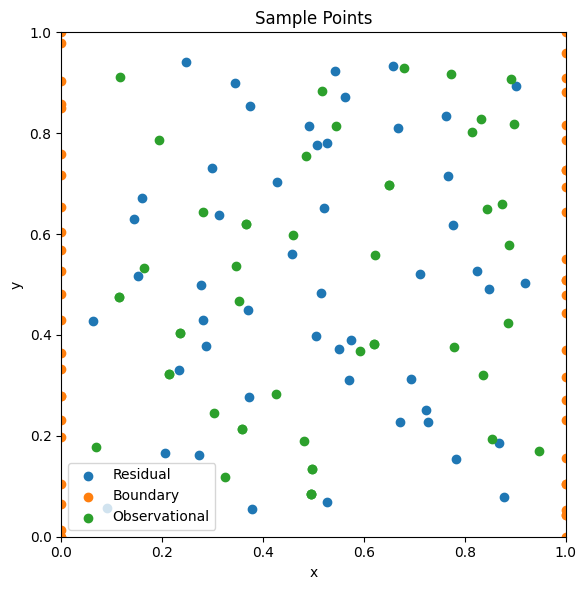

In [4]:
sampler = SQUARESampler(
    interior_h=0.05,
    boundary_h=0.05,
    initial_h=None,
    batch_size=50,
    padding=0.1,
    keep_ratio=False,
    resample=True,
    remove=["bottom", "top"]
)

num_batches = sampler.generate()
print("Number of batches: ", num_batches)

batch = sampler.batch(0)
metrics = sampler.metrics()

plot_samples(
    residual=batch.residual["x"],
    boundary=batch.boundary["x"] if batch.boundary is not None else None,
    observational=batch.observational["x"] if batch.observational is not None else None,
    initial=batch.initial["x"] if batch.initial is not None else None,
    metrics=None,#metrics["x"] if metrics is not None else None,
)